In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Ferramentas importadas com sucesso")

Ferramentas importadas com sucesso


In [4]:
url_clima = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv"
df_clima_bruto = pd.read_csv(url_clima)

url_vendas = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly-shampoo-sales.csv"
df_vendas_bruto = pd.read_csv(url_vendas)

df_filial_A = df_vendas_bruto.iloc[:18].copy()
df_filial_B = df_vendas_bruto.iloc[18:].copy()

print("--- Dados Carregados e Fragmentados ---")
print(f"Registos extraídos da Fonte Clima: {len(df_clima_bruto)} linhas.")
print(f"Registos extraídos da Fonte Filial A: {len(df_filial_A)} linhas.")
print(f"Registos extraídos da Fonte Filial B: {len(df_filial_B)} linhas.")

--- Dados Carregados e Fragmentados ---
Registos extraídos da Fonte Clima: 3650 linhas.
Registos extraídos da Fonte Filial A: 18 linhas.
Registos extraídos da Fonte Filial B: 18 linhas.


In [5]:
df_vendas_consolidado = pd.concat([df_filial_A, df_filial_B], axis=0)

df_clima_bruto['Date'] = pd.to_datetime(df_clima_bruto['Date'])

df_vendas_consolidado['Date'] = pd.date_range(start=df_clima_bruto['Date'].min(), periods=len(df_vendas_consolidado), freq='D')

df_clima_bruto.rename(columns={'Date': 'Data_Chave', 'Temp': 'Temperatura_C'}, inplace=True)
df_vendas_consolidado.rename(columns={'Date': 'Data_Chave', 'Sales': 'Faturacao_Euros'}, inplace=True)

df_projeto_final = pd.merge(df_clima_bruto, df_vendas_consolidado, on='Data_Chave', how='inner')

print("Primeiras linhas do dataset integrado final:")
print(df_projeto_final.head())

Primeiras linhas do dataset integrado final:
  Data_Chave  Temperatura_C Month  Faturacao_Euros
0 1981-01-01           20.7  1-01            266.0
1 1981-01-02           17.9  1-02            145.9
2 1981-01-03           18.8  1-03            183.1
3 1981-01-04           14.6  1-04            119.3
4 1981-01-05           15.8  1-05            180.3


In [7]:
print("1. Verificação de Dados em Falta (Nulos):")
print(df_projeto_final.isnull().sum())

df_projeto_final['Temperatura_C'] = df_projeto_final['Temperatura_C'].fillna(df_projeto_final['Temperatura_C'].mean())

print("\n2. Identificação e Tratamento Estatístico de Outliers:")

media_vendas = df_projeto_final['Faturacao_Euros'].mean()
print(f"-> Média das Vendas: {media_vendas:.2f}€")

desvio_vendas = df_projeto_final['Faturacao_Euros'].std()

limite_superior = media_vendas + (2 * desvio_vendas)
print(f"-> Limite Superior: {limite_superior:.2f}€")

outliers = df_projeto_final[df_projeto_final['Faturacao_Euros'] > limite_superior]
print(f"-> Quantidade de outliers detetados: {len(outliers)}")

df_projeto_final.loc[df_projeto_final['Faturacao_Euros'] > limite_superior, 'Faturacao_Euros'] = limite_superior
print("--- Capping Concluído ---")

print("\n3. Validação do Capping:")
val_max_vendas = df_projeto_final['Faturacao_Euros'].max()
print(f"-> O novo valor máximo de faturação na tabela é: {val_max_vendas:.2f}€")

if val_max_vendas <= limite_superior:
    print("Validação com sucesso! Nenhum valor ultrapassa o limite.")
else:
    print("O capping falhou.")

1. Verificação de Dados em Falta (Nulos):
Data_Chave         0
Temperatura_C      0
Month              0
Faturacao_Euros    0
dtype: int64

2. Identificação e Tratamento Estatístico de Outliers:
-> Média das Vendas: 309.60€
-> Limite Superior: 593.51€
-> Quantidade de outliers detetados: 2
--- Capping Concluído ---

3. Validação do Capping:
-> O novo valor máximo de faturação na tabela é: 593.51€
Validação com sucesso! Nenhum valor ultrapassa o limite.


--- Tabela de Estatística Descritiva Final ---
       Temperatura_C  Faturacao_Euros
count      36.000000        36.000000
mean       17.822222       308.659061
std         2.994577       139.942042
min        12.100000       119.300000
25%        15.725000       192.450000
50%        17.300000       280.150000
75%        19.925000       411.100000
max        25.000000       593.513095


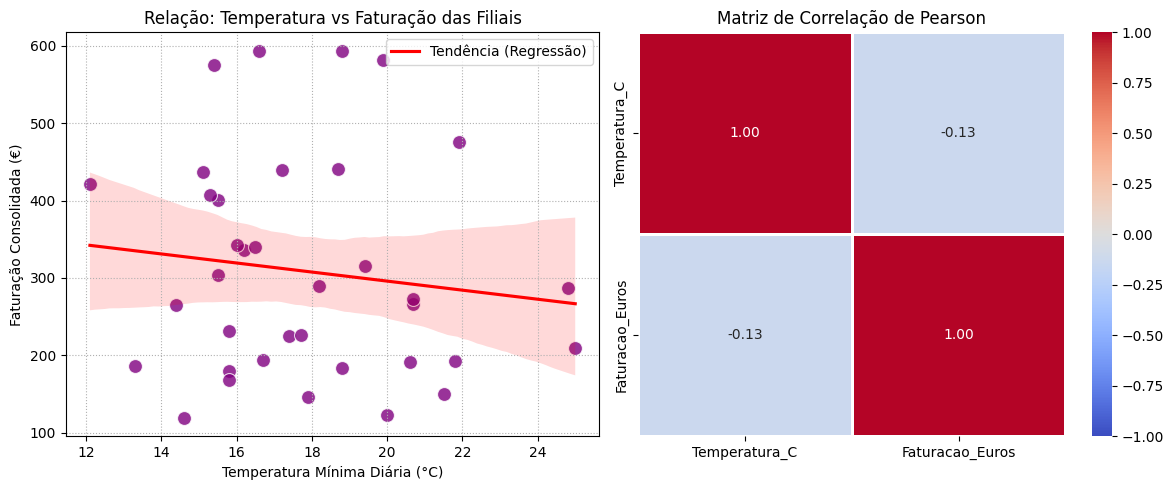

In [8]:
print("--- Tabela de Estatística Descritiva Final ---")
print(df_projeto_final[['Temperatura_C', 'Faturacao_Euros']].describe())

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(data=df_projeto_final, x='Temperatura_C', y='Faturacao_Euros', color='purple', s=100, alpha=0.8)
sns.regplot(data=df_projeto_final, x='Temperatura_C', y='Faturacao_Euros', scatter=False, color='red', label='Tendência (Regressão)')
plt.title('Relação: Temperatura vs Faturação das Filiais')
plt.xlabel('Temperatura Mínima Diária (°C)')
plt.ylabel('Faturação Consolidada (€)')
plt.grid(True, linestyle=':')
plt.legend()

plt.subplot(1, 2, 2)
colunas_numericas = df_projeto_final[['Temperatura_C', 'Faturacao_Euros']]
matriz_correlacao = colunas_numericas.corr(method='pearson')

sns.heatmap(matriz_correlacao, annot=True, cmap='coolwarm', fmt=".2f", linewidths=1, vmin=-1, vmax=1)
plt.title('Matriz de Correlação de Pearson')

plt.tight_layout()
plt.show()